# Notebook 1: Baseline Correspondence Network
**Luis Mitrovic Balbontín Archive**

This notebook constructs a baseline correspondence network from the metadata of 141 letters (sender, recipient, date, origin, destination) without NER or content analysis. Establishes what the archive reveals through structure alone, serving as the reference point for the enriched network produced in later phases.

**Inputs:** `data/raw/LuisMitrovic_Cartas.csv`  
**Outputs:** Descriptive corpus statistics · Directed network (53 nodes, 56 edges) · `figures/baseline_timeline.png`

**Key findings:** 82% of letters received by Mitrovic · 47% concentrate in 1935–1937 (Vienna/Weimar) · 50 locations across 18 countries · 5 reciprocal correspondences (Reiss, Gana, Nora, Dijkstra, Club Alemán de Excursionismo)

In [1]:
from pathlib import Path

# Path configuration
# Set BASE to the root of the repository.
# If running locally after cloning, this resolves automatically.
# If needed, override manually: BASE = Path("/your/local/path")

BASE = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
DATA_RAW   = BASE / "data" / "raw"
DATA_PROC  = BASE / "data" / "processed"
FIGURES    = BASE / "figures"

print(f"BASE: {BASE}")
print(f"DATA_RAW: {DATA_RAW}")

BASE: C:\Users\felip\mitrovic-archive
DATA_RAW: C:\Users\felip\mitrovic-archive\data\raw


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
from datetime import datetime

df = pd.read_csv(DATA_RAW / "LuisMitrovic_Cartas.csv", sep=';', encoding='utf-8-sig')

# Parse dates
df['DateParsed'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

print(f"Total letters: {len(df)}")
print(f"Date range: {df['DateParsed'].min()} — {df['DateParsed'].max()}")
print(f"Letters with valid dates: {df['DateParsed'].notna().sum()}")
print(f"Languages: {df['Language'].value_counts().to_dict()}")
print(f"Unique senders: {df['From'].nunique()}")
print(f"Unique recipients: {df['To'].nunique()}")

Total letters: 141
Date range: 1934-09-05 00:00:00 — 2006-07-30 00:00:00
Letters with valid dates: 134
Languages: {'English': 58, 'Spanish': 46, 'German': 37}
Unique senders: 45
Unique recipients: 18


In [3]:
# BASELINE NETWORK: Correspondence metadata exploration


# Who writes to whom? 
print("TOP SENDERS (by letter count):")
print(df['From'].value_counts().to_string())

print(f"\nTOP RECIPIENTS:")
print(df['To'].value_counts().to_string())

# Temporal distribution
print(f"\nLETTERS BY DECADE:")
df_dated = df[df['DateParsed'].notna()].copy()
df_dated['Decade'] = (df_dated['DateParsed'].dt.year // 10) * 10
print(df_dated['Decade'].value_counts().sort_index().to_string())

# Geographic coverage
print(f"\nPLACES OF ORIGIN (placeFrom):")
print(df['placeFrom'].value_counts().to_string())

print(f"\nPLACES OF DESTINATION (placeTo):")
print(df['placeTo'].value_counts().to_string())

# Language by sender
print(f"\nLANGUAGE BY SENDER:")
lang_sender = df.groupby(['From', 'Language']).size().reset_index(name='count')
for _, row in lang_sender.sort_values('count', ascending=False).iterrows():
    print(f"  {row['From']:<35} {row['Language']:<10} {row['count']}")

TOP SENDERS (by letter count):
From
Winold Tjark Reiss                     18
Rolf Altenburger                       15
Luis Mitrovic Balbontín                14
Angela Gana                            10
Gonzalo Latorre Salamanca               8
Nora                                    7
John G. Dijkstra                        5
Baburizza & Company LTD                 4
Jorge Hubner Gallo                      4
Unknown                                 4
Franz J. Kranl                          4
John Grisar                             3
Eugen Himmel                            3
Luis Mitrovic                           2
Herbert Fronisius                       2
Howard F. Elkus                         2
Matias Astoreca Sartori                 2
Club Alemán de Excursionismo            2
O. B. Y.                                1
Luis Arteaga                            1
George H. Watson                        1
John Jay\nc/o Francis Boardman          1
Roland Palmedo                          

In [4]:
# DATA CLEANING

name_mapping = {
    'Luis Mitrovic': 'Luis Mitrovic Balbontín',
    'John Jay\nc/o Francis Boardman': 'John Jay',
    'Ridgeway\nLeatherhead\nSurrey, Great Britain': 'Surrey, Great Britain',
}

df['From_clean'] = df['From'].replace(name_mapping)
df['To_clean'] = df['To'].replace(name_mapping)

# Normalize places
place_mapping = {
    'Providencia, Santiago, Chile': 'Santiago, Chile',
    'Unkown': 'Unknown',
    'Amberes, Belgium': 'Antwerp, Belgium',
    'Lapad, Dubrovnik, Yugoslavia': 'Dubrovnik, Croatia',
}

df['placeFrom_clean'] = df['placeFrom'].replace(place_mapping)
df['placeTo_clean'] = df['placeTo'].replace(place_mapping)

# Fill NaN before network construction
df['From_clean'] = df['From_clean'].fillna('Unknown')
df['To_clean'] = df['To_clean'].fillna('Unknown')

# Verify
print(f"Unique senders after cleanup: {df['From_clean'].nunique()}")
print(f"Unique recipients after cleanup: {df['To_clean'].nunique()}")
print(f"\nMitrovic as sender: {(df['From_clean'] == 'Luis Mitrovic Balbontín').sum()} letters")
print(f"Mitrovic as recipient: {(df['To_clean'] == 'Luis Mitrovic Balbontín').sum()} letters")

Unique senders after cleanup: 44
Unique recipients after cleanup: 18

Mitrovic as sender: 16 letters
Mitrovic as recipient: 116 letters


In [5]:
# BUILD CORRESPONDENCE NETWORK

G = nx.DiGraph()

for _, row in df.iterrows():
    sender = row['From_clean']
    recipient = row['To_clean']
    
    # Add edge (or increase weight if already exists)
    if G.has_edge(sender, recipient):
        G[sender][recipient]['weight'] += 1
    else:
        G.add_edge(sender, recipient, weight=1)

# Add node attributes
for node in G.nodes():
    sent = df[df['From_clean'] == node].shape[0]
    received = df[df['To_clean'] == node].shape[0]
    G.nodes[node]['letters_sent'] = sent
    G.nodes[node]['letters_received'] = received
    G.nodes[node]['total_activity'] = sent + received
    
    # Is this Mitrovic?
    G.nodes[node]['is_ego'] = (node == 'Luis Mitrovic Balbontín')

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Total letter-connections: {sum(d['weight'] for _, _, d in G.edges(data=True))}")

# Key metrics
print(f"\nTOP 10 BY DEGREE (total connections):")
degree = sorted(G.nodes(), key=lambda n: G.degree(n, weight='weight'), reverse=True)
for n in degree[:10]:
    in_w = G.in_degree(n, weight='weight')
    out_w = G.out_degree(n, weight='weight')
    print(f"  {n:<35} in:{in_w:>3}  out:{out_w:>3}  total:{in_w+out_w:>3}")

# Reciprocity: who does Mitrovic write back to?
print(f"\nRECIPROCITY (Mitrovic sends AND receives):")
ego = 'Luis Mitrovic Balbontín'
mitrovic_sends_to = set(G.successors(ego))
mitrovic_receives_from = set(G.predecessors(ego))
reciprocal = mitrovic_sends_to & mitrovic_receives_from

for person in reciprocal:
    sent = G[ego][person]['weight']
    received = G[person][ego]['weight']
    print(f"  {person:<35} sent:{sent:>2}  received:{received:>2}")

non_reciprocal = mitrovic_receives_from - mitrovic_sends_to
print(f"\nONE-WAY correspondents (write to Mitrovic, no reply in archive): {len(non_reciprocal)}")

Network: 53 nodes, 56 edges
Total letter-connections: 141

TOP 10 BY DEGREE (total connections):
  Luis Mitrovic Balbontín             in:116  out: 16  total:132
  Winold Tjark Reiss                  in:  3  out: 18  total: 21
  Rolf Altenburger                    in:  0  out: 15  total: 15
  Unknown                             in:  5  out:  9  total: 14
  Angela Gana                         in:  2  out: 10  total: 12
  Nora                                in:  1  out:  7  total:  8
  Gonzalo Latorre Salamanca           in:  0  out:  8  total:  8
  John G. Dijkstra                    in:  1  out:  5  total:  6
  Jorge Hubner Gallo                  in:  1  out:  4  total:  5
  Baburizza & Company LTD             in:  0  out:  4  total:  4

RECIPROCITY (Mitrovic sends AND receives):
  Winold Tjark Reiss                  sent: 3  received:18
  Angela Gana                         sent: 2  received:10
  Club Alemán de Excursionismo        sent: 1  received: 2
  John G. Dijkstra              

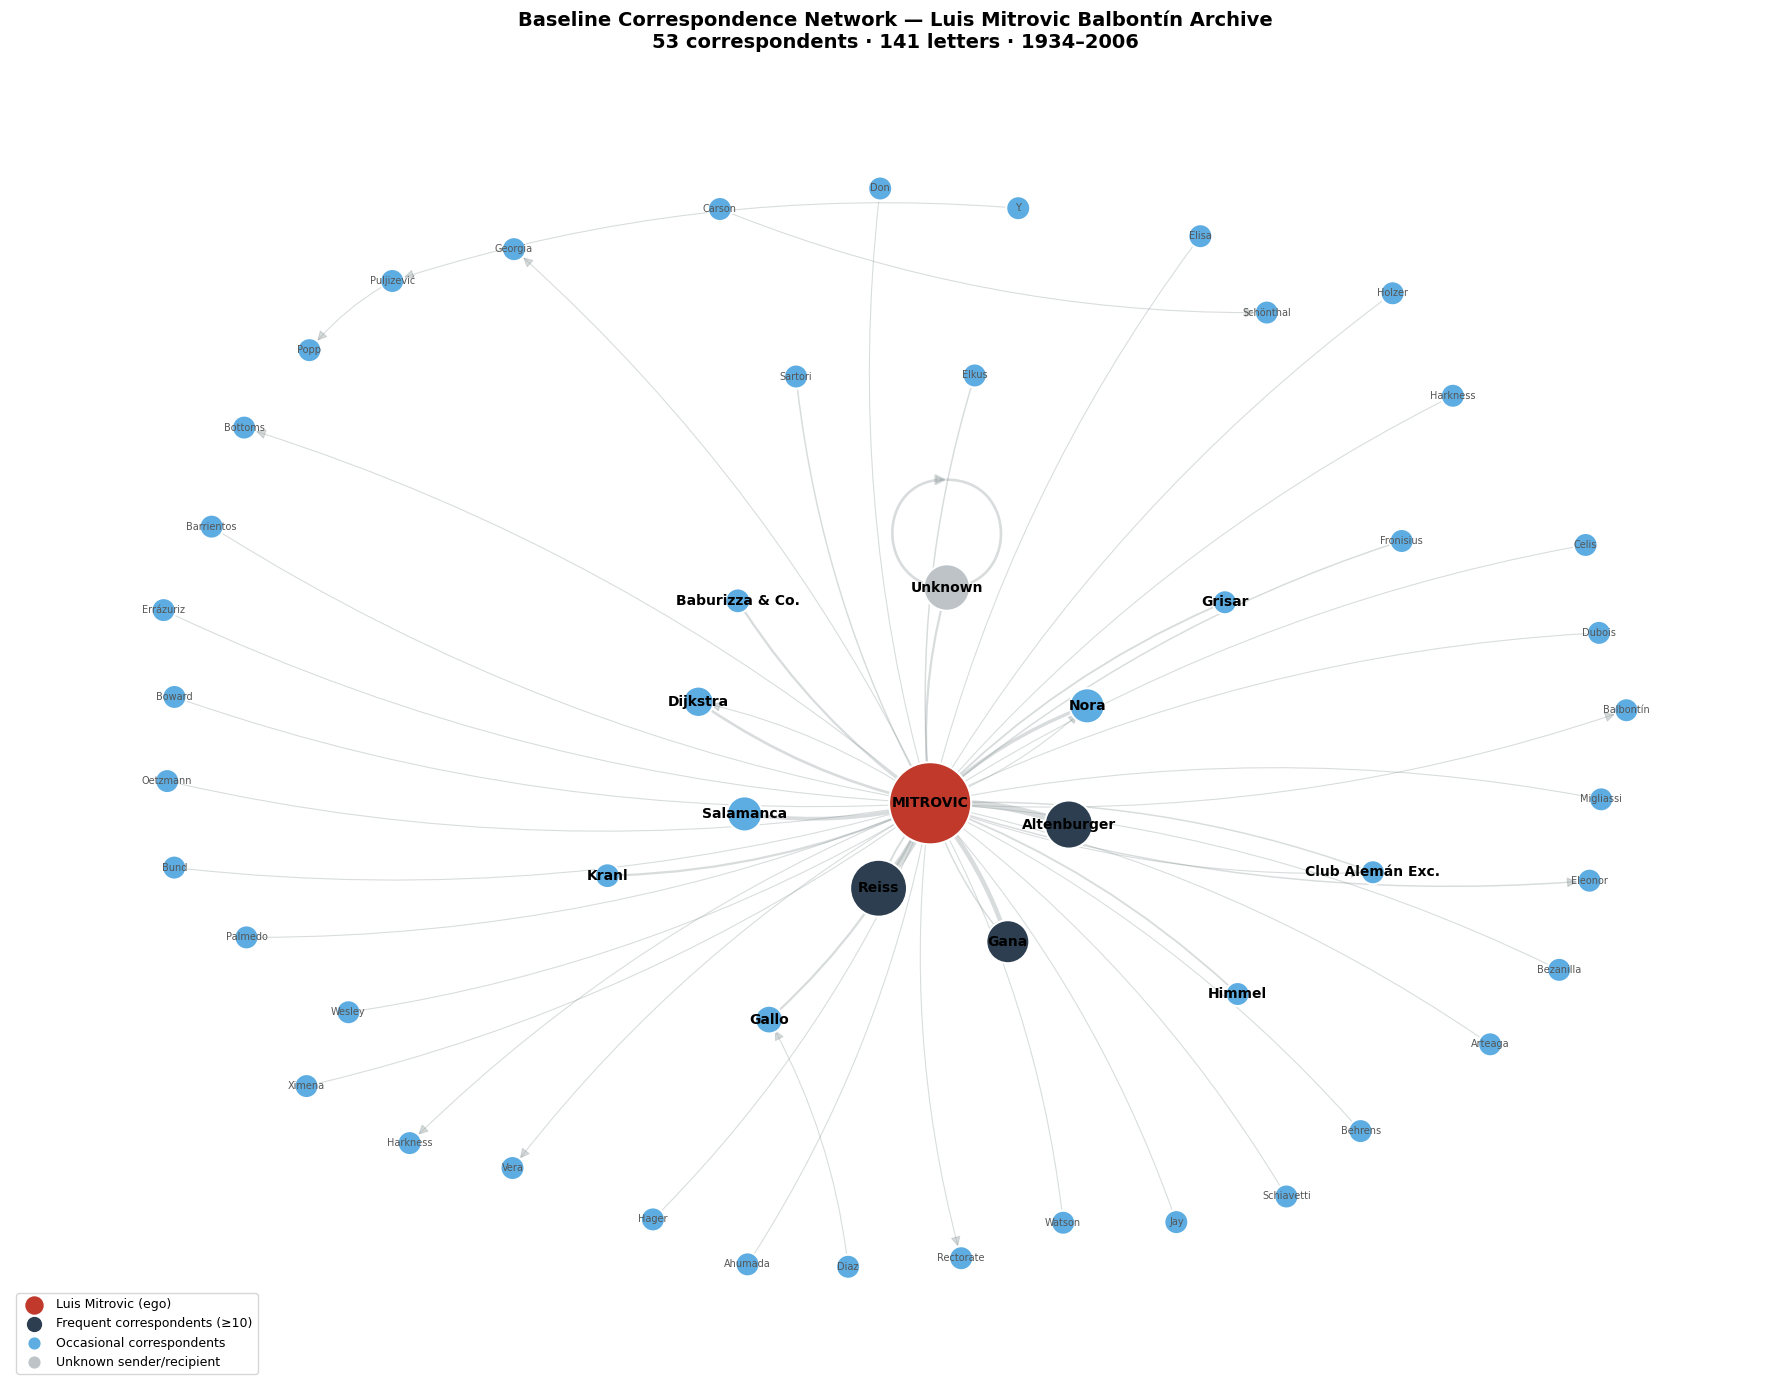

In [6]:
# VISUALIZE BASELINE NETWORK V1

fig, ax = plt.subplots(1, 1, figsize=(18, 14))

# Layout — tighter k for less empty space
pos = nx.spring_layout(G, k=1.8, iterations=100, seed=42, weight='weight')

# Node sizes based on total activity (bigger)
sizes = []
colors = []
for node in G.nodes():
    activity = G.nodes[node]['total_activity']
    if node == 'Luis Mitrovic Balbontín':
        sizes.append(3500)
        colors.append('#C0392B')
    elif node == 'Unknown':
        sizes.append(activity * 80)
        colors.append('#BDC3C7')
    elif activity >= 10:
        sizes.append(activity * 80)
        colors.append('#2C3E50')
    else:
        sizes.append(max(activity * 80, 300))
        colors.append('#5DADE2')

# Edge widths
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(edge_weights)
edge_widths = [0.5 + (w / max_w) * 5 for w in edge_weights]

# Draw edges
nx.draw_networkx_edges(G, pos, ax=ax, 
                        width=edge_widths, 
                        alpha=0.3, 
                        edge_color='#7F8C8D',
                        arrows=True, 
                        arrowsize=15,
                        connectionstyle='arc3,rad=0.1')

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax,
                        node_size=sizes, 
                        node_color=colors, 
                        edgecolors='white', 
                        linewidths=1.5)

# Labels — two tiers, no duplicates
labels_main = {}
labels_minor = {}
for n in G.nodes():
    if n == 'Luis Mitrovic Balbontín':
        short = 'MITROVIC'
    elif n == 'Unknown':
        short = 'Unknown'
    elif n == 'Baburizza & Company LTD':
        short = 'Baburizza & Co.'
    elif n == 'Club Alemán de Excursionismo':
        short = 'Club Alemán Exc.'
    elif ',' in n:
        short = n.split(',')[0]
    else:
        parts = n.split(' ')
        short = parts[-1] if len(parts) > 1 else n
    
    if G.nodes[n]['total_activity'] >= 3 or G.nodes[n]['is_ego']:
        labels_main[n] = short
    else:
        labels_minor[n] = short

nx.draw_networkx_labels(G, pos, labels_main, ax=ax, 
                         font_size=10, font_weight='bold')
nx.draw_networkx_labels(G, pos, labels_minor, ax=ax, 
                         font_size=7, font_color='#555555')

ax.set_title('Baseline Correspondence Network — Luis Mitrovic Balbontín Archive\n'
             f'{G.number_of_nodes()} correspondents · {sum(edge_weights)} letters · '
             f'{df["DateParsed"].min().year}–{df["DateParsed"].max().year}',
             fontsize=14, fontweight='bold', pad=20)

ax.legend(handles=[
    plt.scatter([], [], c='#C0392B', s=150, label='Luis Mitrovic (ego)'),
    plt.scatter([], [], c='#2C3E50', s=100, label='Frequent correspondents (≥10)'),
    plt.scatter([], [], c='#5DADE2', s=60, label='Occasional correspondents'),
    plt.scatter([], [], c='#BDC3C7', s=60, label='Unknown sender/recipient'),
], loc='lower left', fontsize=9)

ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES/ 'baseline_networkv1.png', dpi=150, bbox_inches='tight')
plt.show()

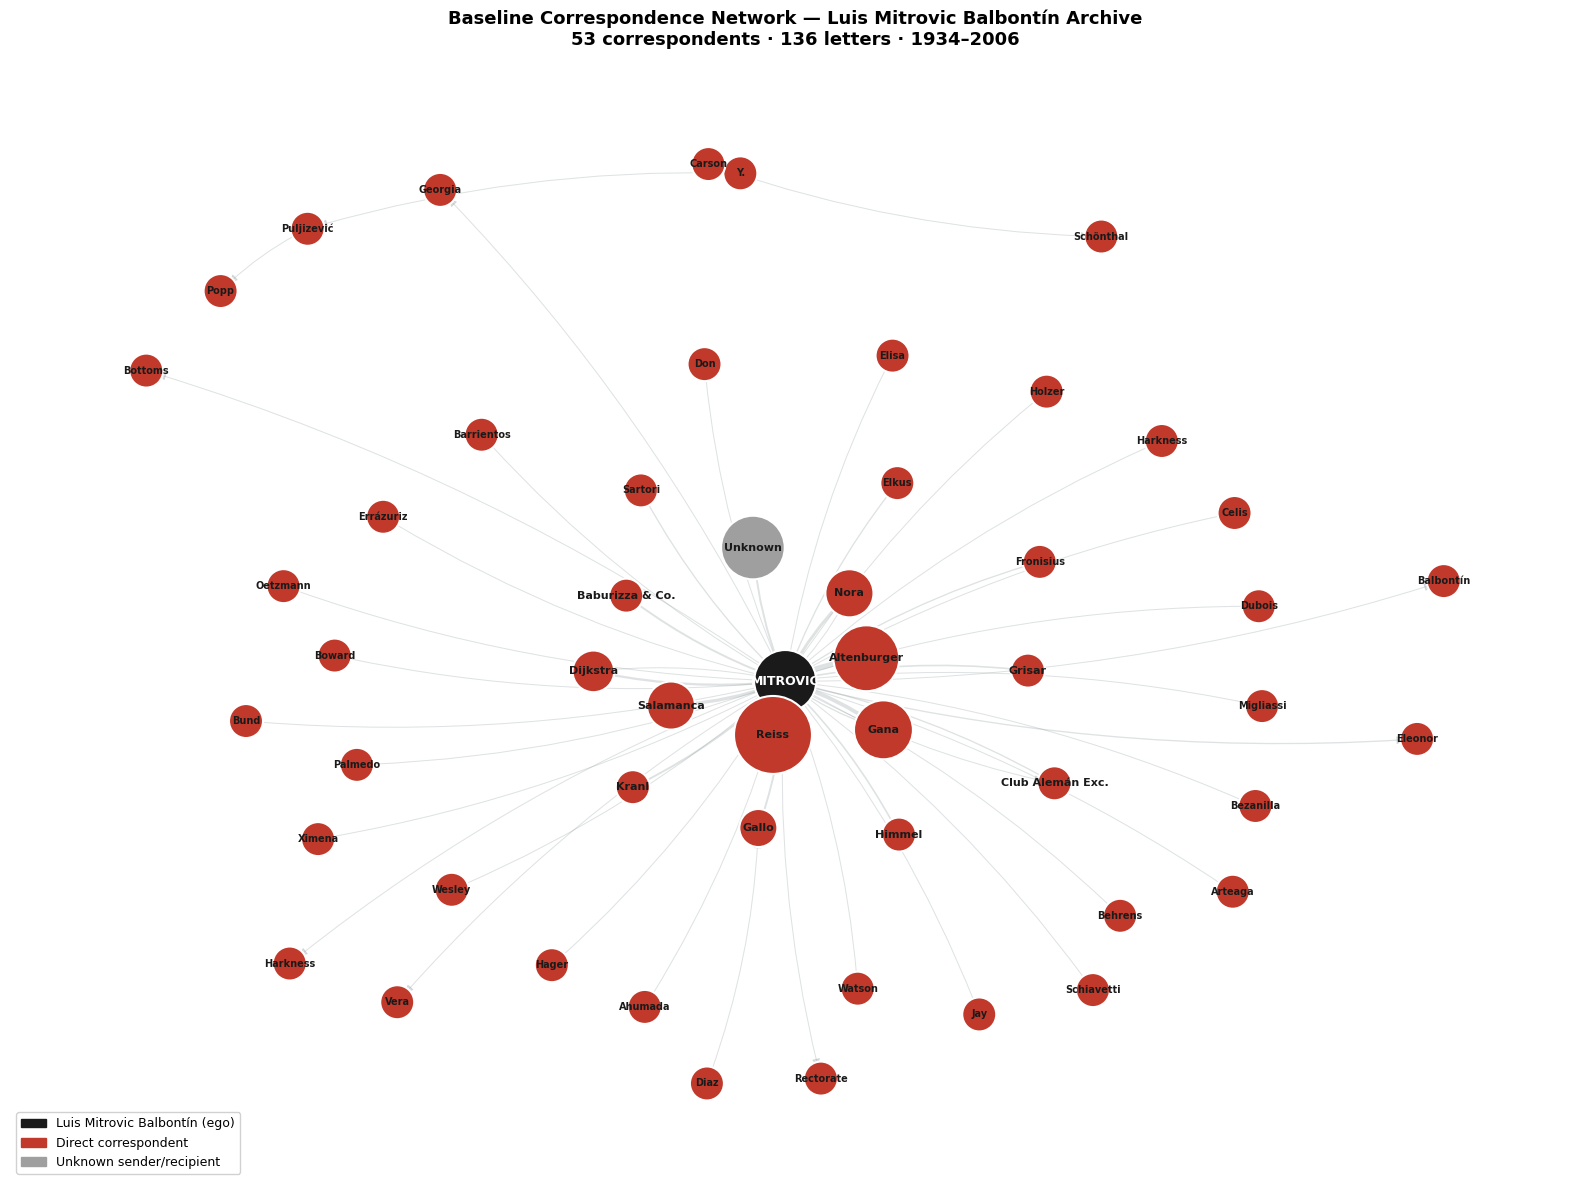

FIG. 1 exported.


In [11]:
# VISUALIZE BASELINE NETWORK V2
#  FIG. 1 — Baseline Correspondence Network
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Visual Design Standards
NODE_COLORS = {
    "ego"                  : "#1A1A1A",
    "direct_correspondent" : "#C0392B",
    "unknown"              : "#9F9F9F",
}

# Remove self-loops
G_plot = G.copy()
G_plot.remove_edges_from(nx.selfloop_edges(G_plot))

# Layout — tighter for compactness
pos = nx.spring_layout(G_plot, k=1.8, iterations=150, seed=42, weight='weight', scale=2.5)

# Node sizes and colors 
sizes  = []
colors = []

for node in G_plot.nodes():
    activity = G_plot.nodes[node].get('total_activity', 1)
    if node == 'Luis Mitrovic Balbontín':
        sizes.append(2000)                         
        colors.append(NODE_COLORS["ego"])
    elif node == 'Unknown':
        sizes.append(max(activity * 150, 600))      
        colors.append(NODE_COLORS["unknown"])
    else:
        sizes.append(max(activity * 150, 600))      
        colors.append(NODE_COLORS["direct_correspondent"])

# Edge widths
edge_weights = [G_plot[u][v]['weight'] for u, v in G_plot.edges()]
max_w        = max(edge_weights) if edge_weights else 1
edge_widths  = [0.5 + (w / max_w) * 4 for w in edge_weights]

# Draw 
fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_edges(G_plot, pos, ax=ax,
                       width=edge_widths,
                       alpha=0.25,
                       edge_color='#7F8C8D',
                       arrows=True,
                       arrowsize=12,
                       connectionstyle='arc3,rad=0.08')

nx.draw_networkx_nodes(G_plot, pos, ax=ax,
                       node_size=sizes,
                       node_color=colors,
                       edgecolors='white',
                       linewidths=1.5)

# Labels — two tiers
labels_main  = {}
labels_minor = {}

for n in G_plot.nodes():
    if n == 'Luis Mitrovic Balbontín':
        short = 'MITROVIC'
    elif n == 'Unknown':
        short = 'Unknown'
    elif n == 'Baburizza & Company LTD':
        short = 'Baburizza & Co.'
    elif n == 'Club Alemán de Excursionismo':
        short = 'Club Alemán Exc.'
    elif ',' in n:
        short = n.split(',')[0]
    else:
        parts = n.split(' ')
        short = parts[-1] if len(parts) > 1 else n

    activity = G_plot.nodes[n].get('total_activity', 1)
    if activity >= 3 or n == 'Luis Mitrovic Balbontín':
        labels_main[n]  = short
    else:
        labels_minor[n] = short

nx.draw_networkx_labels(G_plot, pos, labels_main, ax=ax,
                        font_size=8, font_weight='bold',
                        font_color='#1A1A1A')

nx.draw_networkx_labels(G_plot, pos, labels_minor, ax=ax,
                        font_size=7, font_weight='bold',
                        font_color='#1A1A1A')


ego_label = {'Luis Mitrovic Balbontín': 'MITROVIC'}
nx.draw_networkx_labels(G_plot, pos, ego_label, ax=ax,
                        font_size=9, font_weight='bold',
                        font_color='white')        

# Legend 
legend_handles = [
    mpatches.Patch(color=NODE_COLORS["ego"],
                   label='Luis Mitrovic Balbontín (ego)'),
    mpatches.Patch(color=NODE_COLORS["direct_correspondent"],
                   label='Direct correspondent'),
    mpatches.Patch(color=NODE_COLORS["unknown"],
                   label='Unknown sender/recipient'),
]
ax.legend(handles=legend_handles, loc='lower left',
          fontsize=9, framealpha=0.9)

# Title 
total_letters = sum(edge_weights)
ax.set_title(
    'Baseline Correspondence Network — Luis Mitrovic Balbontín Archive\n'
    f'{G_plot.number_of_nodes()} correspondents · {total_letters} letters · '
    f'{df["DateParsed"].min().year}–{df["DateParsed"].max().year}',
    fontsize=13, fontweight='bold', pad=16
)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES / 'baseline_networkv2.png', dpi=150, bbox_inches='tight')
plt.show()
print("FIG. 1 exported.")

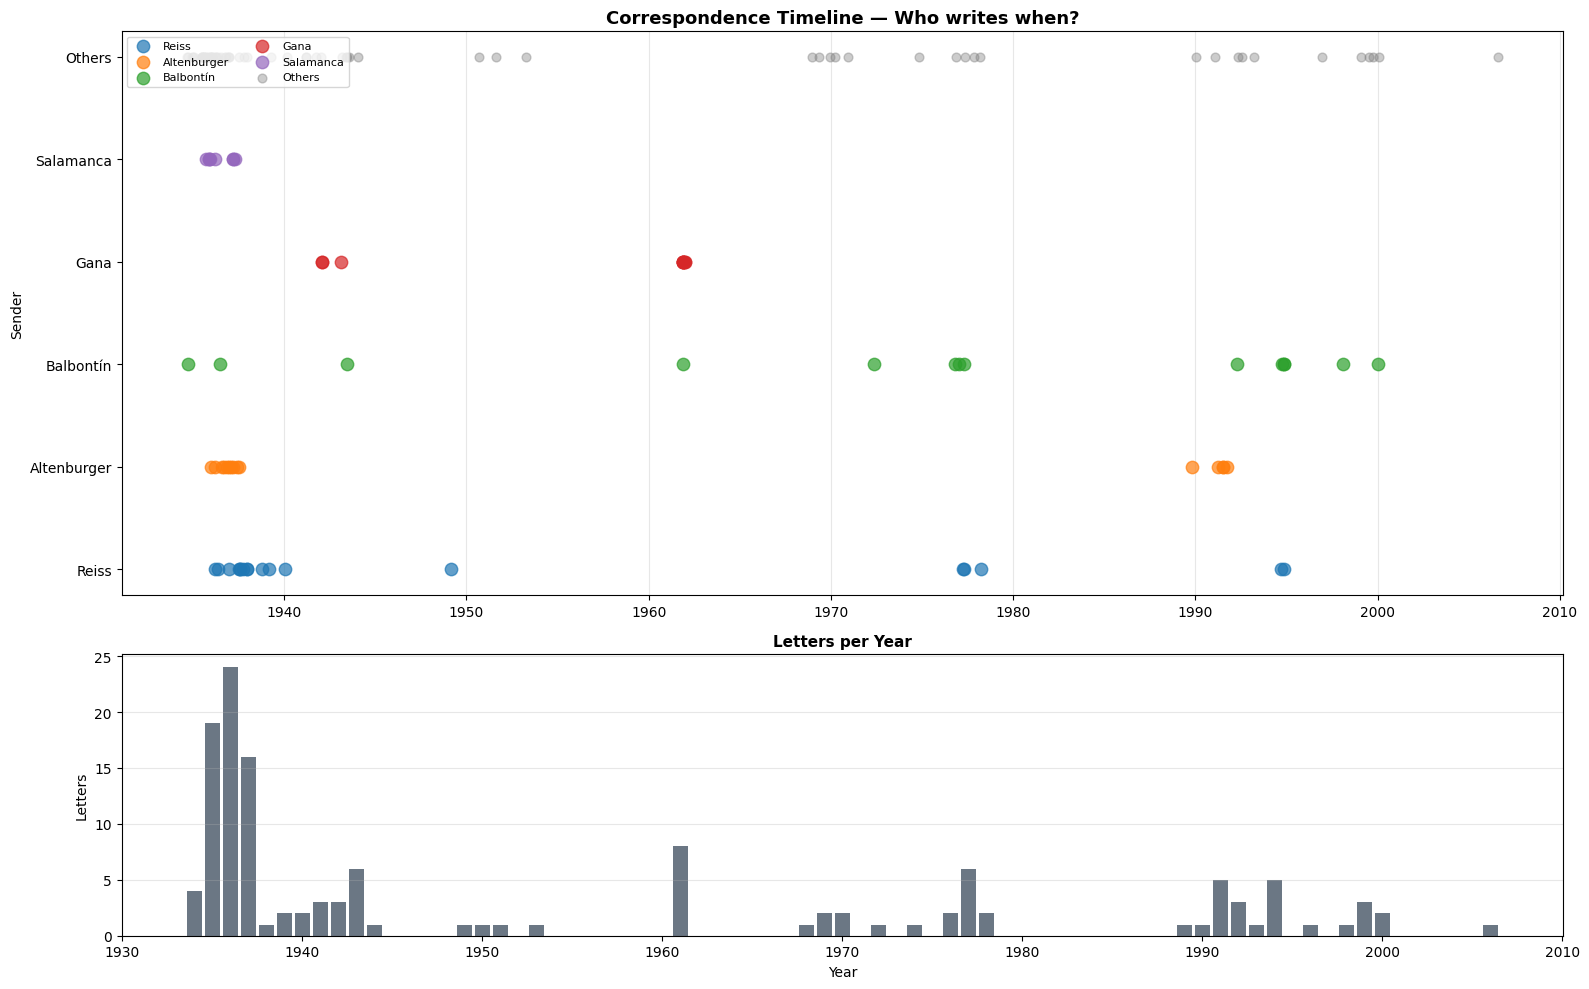

In [8]:
# TEMPORAL DISTRIBUTION OF CORRESPONDENCE

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

df_dated = df[df['DateParsed'].notna()].copy()

# Plot 1: Letters over time, colored by top senders
top_senders = df_dated['From_clean'].value_counts().head(5).index.tolist()

ax1 = axes[0]
for sender in top_senders:
    subset = df_dated[df_dated['From_clean'] == sender]
    ax1.scatter(subset['DateParsed'], [sender.split(' ')[-1]] * len(subset), 
                s=80, alpha=0.7, zorder=3, label=sender.split(' ')[-1])

# All others
others = df_dated[~df_dated['From_clean'].isin(top_senders)]
ax1.scatter(others['DateParsed'], ['Others'] * len(others), 
            s=40, alpha=0.4, color='grey', zorder=2, label='Others')

ax1.set_title('Correspondence Timeline — Who writes when?', fontsize=13, fontweight='bold')
ax1.set_ylabel('Sender')
ax1.legend(loc='upper left', fontsize=8, ncol=2)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Histogram of letters per year
ax2 = axes[1]
df_dated['Year'] = df_dated['DateParsed'].dt.year
year_counts = df_dated['Year'].value_counts().sort_index()
ax2.bar(year_counts.index, year_counts.values, color='#2C3E50', alpha=0.7)
ax2.set_xlabel('Year')
ax2.set_ylabel('Letters')
ax2.set_title('Letters per Year', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\felip\Tesis\baseline_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

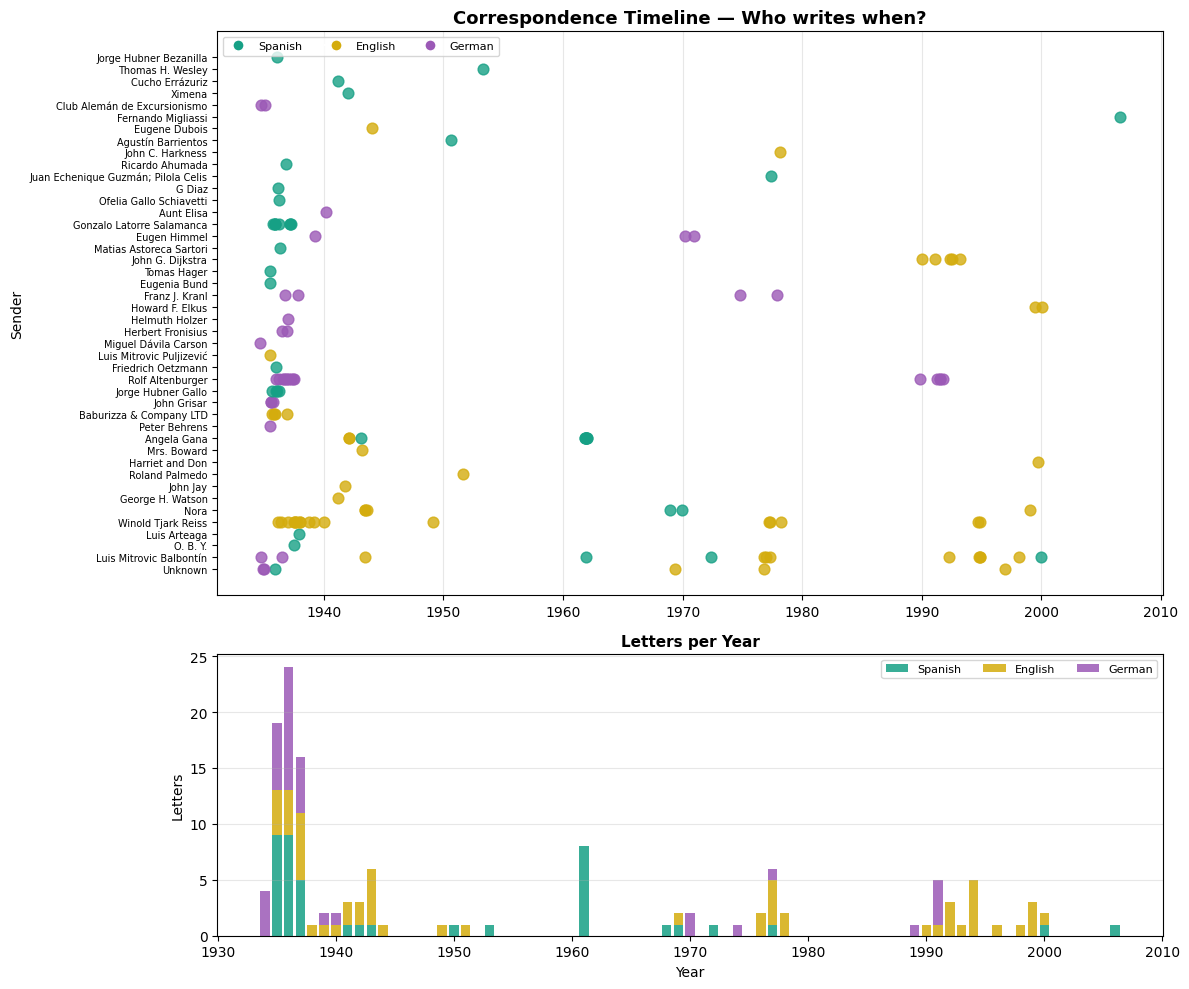

In [9]:
# TEMPORAL DISTRIBUTION OF CORRESPONDENCE — language palette

LANG_COLORS = {
    'Spanish': '#16A085',
    'English': '#D4AC0D',
    'German':  '#9B59B6',
}
LANG_DEFAULT = '#9F9F9F'  # Mixed / unknown

fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

df_dated = df[df['DateParsed'].notna()].copy()

# Panel A — scatter by sender, colored by language
ax1 = axes[0]

# Collect unique senders sorted by total letters descending
sender_order = (df_dated['From_clean']
                .value_counts()
                .index.tolist())

for _, row in df_dated.iterrows():
    color = LANG_COLORS.get(row['Language'], LANG_DEFAULT)
    ax1.scatter(row['DateParsed'], row['From_clean'],
                s=60, alpha=0.8, color=color, zorder=3)

# Legend for language
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=v, markersize=8, label=k)
    for k, v in LANG_COLORS.items()
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=3)
ax1.set_ylabel('Sender', fontsize=10)
ax1.set_title('Correspondence Timeline — Who writes when?', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='y', labelsize=7)

# Panel B — histogram colored by language, stacked
ax2 = axes[1]
df_dated['Year'] = df_dated['DateParsed'].dt.year

lang_year = (df_dated.groupby(['Year', 'Language'])
             .size()
             .unstack(fill_value=0))

bottom = None
for lang, color in LANG_COLORS.items():
    if lang in lang_year.columns:
        vals = lang_year[lang]
        ax2.bar(lang_year.index, vals,
                bottom=bottom,
                color=color, alpha=0.85,
                label=lang)
        bottom = vals if bottom is None else bottom + vals

ax2.set_xlabel('Year')
ax2.set_ylabel('Letters')
ax2.set_title('Letters per Year', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, ncol=3)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "baseline_timeline.png", dpi=150, bbox_inches='tight')
plt.show()